# 02 — Cleaning Pipeline Demo

This notebook does not produce data — `python -m src.cleaning` does. This notebook **demonstrates** what cleaning does, for slide screenshots and report figures.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src.cleaning import clean_text
from src.data import load_and_cache_raw
from src.utils import RESULTS_DIR

EDA_DIR = RESULTS_DIR / 'eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load raw data (un-cleaned)

In [2]:
raw = load_and_cache_raw()
print(f'Raw shape: {raw.shape}')
raw.head(2)

12:39:55 | src.data | INFO | Loading cached raw data from E:\mlds\MLDS 414 NLP\final\data\multilexsum_raw.parquet
Raw shape: (4539, 12)


,case_id,source_text,n_source_docs,long_ref,short_ref,tiny_ref,class_action_sought,case_type_raw,filing_date,court,state,split
0,EE-AL-0045,Case 1:05-cv-00530-D Document 1-1 Filed 09/19/...,4,"On September 15, 2005, the Equal Employment Op...",Equal Employment Opportunity Commission brough...,None,False,Equal Employment,2005-09-15,None,None,train
1,PB-NJ-0003,Case 3:05-cv-01784-SRC-JJH Document 2 Filed 05...,4,NOTE: This is one of three identically named ...,The case was brought by a non-profit organizat...,None,False,Public Benefits / Government Services,2005-04-05,None,None,train


## 2. Before / after on a sample case

In [3]:
sample = raw[raw['source_text'].str.len() > 5000].iloc[0]
raw_text = sample['source_text']
clean = clean_text(raw_text)

print(f'BEFORE — {len(raw_text):,} chars\n')
print(raw_text[:1500])
print('\n' + '='*70 + '\n')
print(f'AFTER  — {len(clean):,} chars\n')
print(clean[:1500])
print(f'\nReduction: {(1 - len(clean)/len(raw_text))*100:.1f}%')

BEFORE — 32,207 chars

Case 1:05-cv-00530-D Document 1-1 Filed 09/19/2005 Page 1 of 6

IN

THE

UNITED

STATES

DISTRICT

FILD COUR T

P19

.05

Nl

el

.s

FOR THE SOUTHERN DISTRICT OF ALABAMA

SOUTHERN DIVISION

EQUAL EMPLOYMENT OPPORTUNITY ]

COMMISSION, ]

] Plaintiff, ] Civil Action No. OSS- 0'53a -~

v.

]

]
COMPLAINT

] HOUSE OF PHILADELPHIA CENTER, INC . ]

JURY TRIAL DEMAND

Defendant .

]
]
] ]

NATURE OF THE ACTION This is an action under Title VII of the Civil Rights Act of 1964 and Title I of the Civil Rights Act of 1991 to correct unlawful employment practices on the basis of sex and to provide appropriate relief to Sharonda Griffin who was adversely affected by such practices . The Commission alleges that the Defendant discriminated against Sharonda Griffin because of her sex, female .

1

Case 1:05-cv-00530-D Document 1-1 Filed 09/19/2005 Page 2 of 6
JURISDICTION AND VENU E 1 . Jurisdiction of this Court is invoked pursuant to 28 U .S .C. §§ 451, 1331, 1337, 1343 and 

## 3. Aggregate cleaning impact (50-case sample)

In [4]:
import time
import matplotlib.pyplot as plt

subset = raw.head(50).copy()
t0 = time.time()
subset['source_text_clean'] = subset['source_text'].apply(clean_text)
elapsed = time.time() - t0

subset['len_before'] = subset['source_text'].str.len()
subset['len_after']  = subset['source_text_clean'].str.len()
subset['reduction'] = (1 - subset['len_after']/subset['len_before']) * 100

print(f'Processed 50 cases in {elapsed:.1f}s ({elapsed/50*1000:.0f} ms/case)')
print(subset[['len_before', 'len_after', 'reduction']].describe().round(1))

Processed 50 cases in 3.5s (70 ms/case)
       len_before  len_after  reduction
count        50.0       50.0       50.0
mean     495818.0   480984.4        3.1
std     1299627.5  1258122.9        0.8
min       10975.0    10406.0        1.6
25%       60708.8    58373.0        2.4
50%      178081.5   172937.0        3.1
75%      388416.0   378356.5        3.7
max     8500437.0  8213139.0        5.2


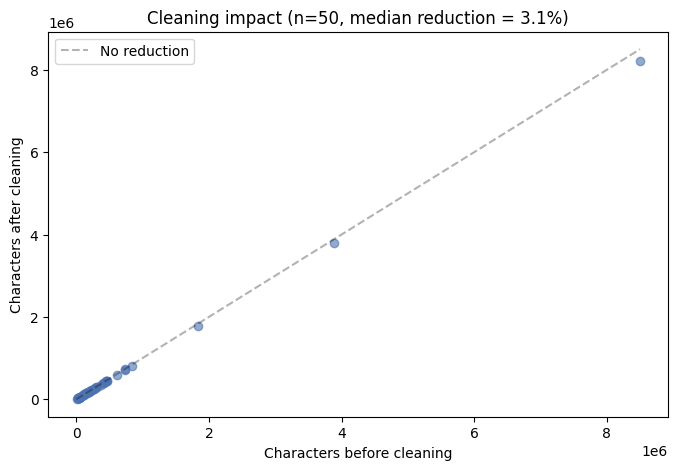

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(subset['len_before'], subset['len_after'], alpha=0.6, color='#4C72B0')
lim = max(subset['len_before'].max(), subset['len_after'].max())
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='No reduction')
ax.set_xlabel('Characters before cleaning')
ax.set_ylabel('Characters after cleaning')
ax.set_title(f'Cleaning impact (n=50, median reduction = '
             f"{subset['reduction'].median():.1f}%)")
ax.legend()
plt.savefig(EDA_DIR / 'cleaning_impact.png')
plt.show()

## 4. Specific regex pattern hit counts

In [6]:
import re
from src.cleaning import (_PAGE_MARKER_RE, _CITATION_RE, _USC_RE,
                          _CFR_RE, _FOOTNOTE_RE)

patterns = {
    'page markers':  _PAGE_MARKER_RE,
    'reporter cites': _CITATION_RE,
    'U.S.C. refs':    _USC_RE,
    'C.F.R. refs':    _CFR_RE,
    'footnote nums':  _FOOTNOTE_RE,
}

rows = []
for name, pat in patterns.items():
    hits = subset['source_text'].apply(lambda t: len(pat.findall(t or '')))
    rows.append({
        'pattern': name,
        'cases_hit': (hits > 0).sum(),
        'total_matches': hits.sum(),
        'mean_per_case': hits.mean(),
    })
pd.DataFrame(rows).round(1)

,pattern,cases_hit,total_matches,mean_per_case
0,page markers,44,5263,105.3
1,reporter cites,47,30699,614.0
2,U.S.C. refs,49,3156,63.1
3,C.F.R. refs,17,696,13.9
4,footnote nums,14,384,7.7
